# Two-dimensional diffusion with mixed boundary conditions

This notebook supports the Chapter 6 lecture. We first visualize nodal basis functions on an 18-triangle mesh. We then solve one diffusion problem on meshes with 4, 16, and 64 triangles and measure the $L^2$ error.

## Imports and plotting helpers
Run these cells before executing the remaining notebook. The plotting functions keep figure construction separate from the finite element algorithm discussed later.

In [1]:
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.sparse import csr_matrix
import ufl
from dolfinx import fem, mesh, plot
from dolfinx.fem.petsc import LinearProblem

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

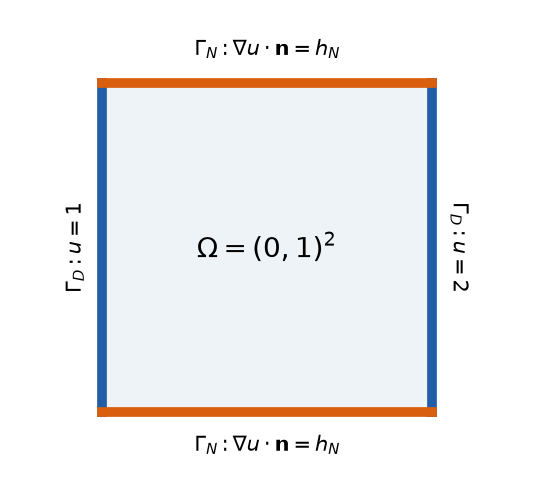

In [2]:
def triangulation_for(V):
    cells, _, coordinates = plot.vtk_mesh(V)
    triangles = cells.reshape(-1, 4)[:, 1:]
    tri = mtri.Triangulation(coordinates[:, 0], coordinates[:, 1], triangles)
    return tri, coordinates, triangles

def draw_field(ax, V, values, title, show_mesh=True):
    tri, _, _ = triangulation_for(V)
    image = ax.tripcolor(tri, values, shading="gouraud", cmap="viridis")
    if show_mesh:
        ax.triplot(tri, color="black", linewidth=0.7, alpha=0.65)
    ax.set(xlabel="$x$", ylabel="$y$", title=title, aspect="equal")
    return image


fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.fill([0, 1, 1, 0], [0, 0, 1, 1], color="#eef3f7")
ax.plot([0, 0], [0, 1], color="#225ea8", linewidth=7)
ax.plot([1, 1], [0, 1], color="#225ea8", linewidth=7)
ax.plot([0, 1], [0, 0], color="#d95f0e", linewidth=7)
ax.plot([0, 1], [1, 1], color="#d95f0e", linewidth=7)
ax.text(0.5, 0.5, r"$\Omega=(0,1)^2$", ha="center", va="center", fontsize=20)
ax.text(-0.08, 0.5, r"$\Gamma_D: u=1$", ha="center", va="center", rotation=90)
ax.text(1.08, 0.5, r"$\Gamma_D: u=2$", ha="center", va="center", rotation=-90)
ax.text(0.5, -0.10, r"$\Gamma_N: \nabla u\cdot\mathbf{n}=h_N$", ha="center", va="center")
ax.text(0.5, 1.10, r"$\Gamma_N: \nabla u\cdot\mathbf{n}=h_N$", ha="center", va="center")
ax.set_xlim(-0.28, 1.28)
ax.set_ylim(-0.22, 1.22)
ax.set_aspect("equal")
ax.axis("off")
fig.tight_layout()
plt.show()

## 1. A nodal basis function and its support

A $3\times3$ subdivision of the square contains 18 linear triangles and 16 nodal degrees of freedom. For each selected node, set its coefficient equal to one and set every other coefficient equal to zero. The resulting finite element function is the global nodal basis function associated with that node.

In [3]:
basis_mesh = mesh.create_unit_square(
    MPI.COMM_SELF, 3, 3, cell_type=mesh.CellType.triangle
)
V_basis = fem.functionspace(basis_mesh, ("Lagrange", 1))
dof_coordinates = V_basis.tabulate_dof_coordinates()

targets = [
    (np.array([0.0, 0.0]), "corner node"),
    (np.array([1.0 / 3.0, 0.0]), "boundary node"),
    (np.array([1.0 / 3.0, 1.0 / 3.0]), "interior node"),
    (np.array([2.0 / 3.0, 1.0 / 3.0]), "interior node"),
]
selected_dofs = [
    int(np.argmin(np.linalg.norm(dof_coordinates[:, :2] - point, axis=1)))
    for point, _ in targets
]

print("Triangles:", basis_mesh.topology.index_map(2).size_global)
print("Nodal degrees of freedom:", V_basis.dofmap.index_map.size_global)

Triangles: 18
Nodal degrees of freedom: 16


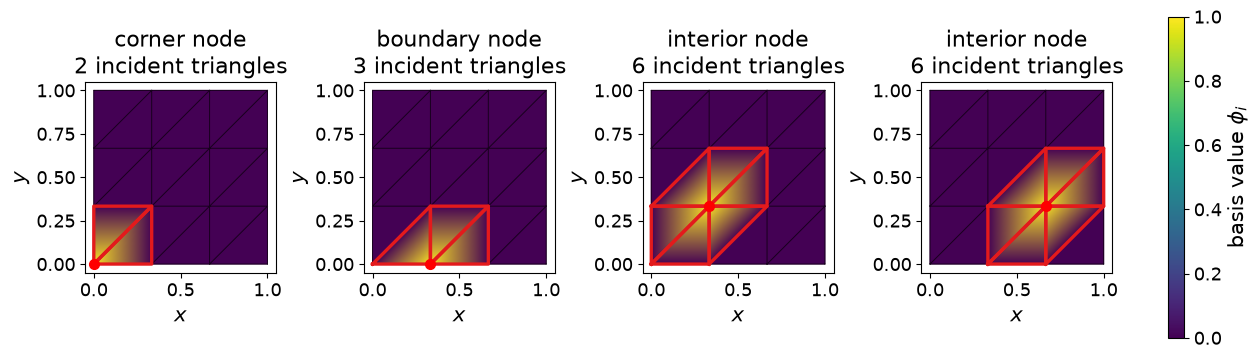

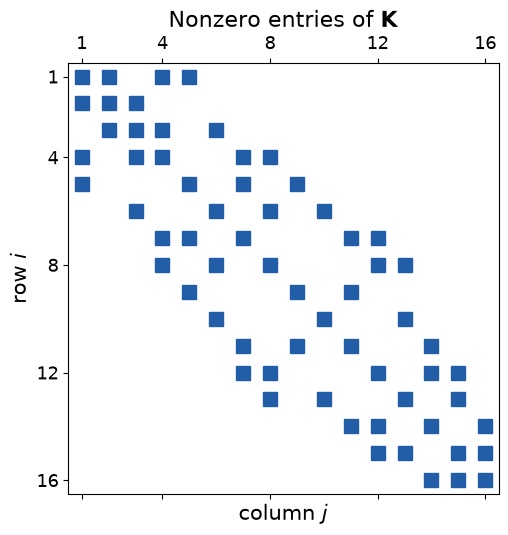

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 4.0), constrained_layout=True)
tri, coordinates, triangles = triangulation_for(V_basis)

for ax, dof, (_, label) in zip(axes, selected_dofs, targets):
    phi = fem.Function(V_basis)
    phi.x.array[:] = 0.0
    phi.x.array[dof] = 1.0
    support_mask = np.any(triangles == dof, axis=1)
    support_cells = int(np.sum(support_mask))
    image = draw_field(
        ax, V_basis, phi.x.array.real,
        f"{label}\n{support_cells} incident triangles"
    )
    for cell in triangles[support_mask]:
        patch = coordinates[np.r_[cell, cell[0]], :2]
        ax.plot(patch[:, 0], patch[:, 1], color="#e31a1c", linewidth=2.4)
    ax.plot(coordinates[dof, 0], coordinates[dof, 1], "ro", markersize=7)

fig.colorbar(image, ax=axes, shrink=0.82, label=r"basis value $\phi_i$")
plt.show()


u_trial = ufl.TrialFunction(V_basis)
v_test = ufl.TestFunction(V_basis)
a_basis = fem.form(ufl.inner(ufl.grad(u_trial), ufl.grad(v_test)) * ufl.dx)
K_petsc = fem.petsc.assemble_matrix(a_basis)
K_petsc.assemble()
row_ptr, column_indices, values = K_petsc.getValuesCSR()
K = csr_matrix((values, column_indices, row_ptr), shape=K_petsc.getSize())
K.eliminate_zeros()

fig, ax = plt.subplots(figsize=(6.0, 5.6))
ax.spy(K, markersize=10, color="#225ea8")
tick_positions = [0, 3, 7, 11, 15]
tick_labels = [1, 4, 8, 12, 16]
ax.set_xticks(tick_positions, tick_labels)
ax.set_yticks(tick_positions, tick_labels)
ax.set(xlabel="column $j$", ylabel="row $i$", title=r"Nonzero entries of $\mathbf{K}$")
fig.tight_layout()
plt.show()

Only triangles containing the selected node contribute to the support. This local support is why most entries of the global stiffness matrix are zero.

## 2. Diffusion problem

Let $\Omega=(0,1)^2$. Prescribe Dirichlet data on the vertical sides and normal flux on the horizontal sides:

$$
-\Delta u=f \quad\text{in }\Omega,\qquad
u=g \quad\text{on }\Gamma_D,\qquad
\nabla u\cdot\boldsymbol n=h_N \quad\text{on }\Gamma_N.
$$

We use the exact solution
$$u_\star(x,y)=1+x+x(1-x)\sin(\pi y).$$
Thus $g=1+x$ on $x=0,1$,
$f=[2+\pi^2x(1-x)]\sin(\pi y)$, and
$h_N=-\pi x(1-x)$ on both $y=0$ and $y=1$.

## 3. One finite element solve

The function below follows the finite element sequence directly: mesh, space, boundary facets, trial and test functions, variational forms, solve, and error. The plotting commands remain outside this function.

In [5]:
def solve_diffusion(nx, ny):
    domain = mesh.create_unit_square(
        MPI.COMM_SELF, nx, ny, cell_type=mesh.CellType.triangle
    )
    V = fem.functionspace(domain, ("Lagrange", 1))

    x = ufl.SpatialCoordinate(domain)
    u_exact = 1 + x[0] + x[0] * (1 - x[0]) * ufl.sin(np.pi * x[1])
    source = (2 + np.pi**2 * x[0] * (1 - x[0])) * ufl.sin(np.pi * x[1])
    normal_flux = -np.pi * x[0] * (1 - x[0])

    facet_dim = domain.topology.dim - 1
    vertical_facets = mesh.locate_entities_boundary(
        domain, facet_dim,
        lambda X: np.isclose(X[0], 0.0) | np.isclose(X[0], 1.0)
    )
    horizontal_facets = mesh.locate_entities_boundary(
        domain, facet_dim,
        lambda X: np.isclose(X[1], 0.0) | np.isclose(X[1], 1.0)
    )
    facet_tags = mesh.meshtags(
        domain, facet_dim, horizontal_facets,
        np.ones(len(horizontal_facets), dtype=np.int32)
    )

    prescribed_dofs = fem.locate_dofs_topological(V, facet_dim, vertical_facets)
    prescribed_value = fem.Function(V)
    prescribed_value.interpolate(lambda X: 1.0 + X[0])
    bc = fem.dirichletbc(prescribed_value, prescribed_dofs)

    trial = ufl.TrialFunction(V)
    test = ufl.TestFunction(V)
    dx = ufl.Measure("dx", domain=domain, metadata={"quadrature_degree": 6})
    ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tags)
    a = ufl.inner(ufl.grad(trial), ufl.grad(test)) * dx
    L = source * test * dx + normal_flux * test * ds(1)

    problem = LinearProblem(
        a, L, bcs=[bc],
        petsc_options_prefix=f"mixed_diffusion_{nx}_{ny}_",
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"}
    )
    u_h = problem.solve()
    u_h.x.scatter_forward()

    error = u_h - u_exact
    error_L2 = np.sqrt(
        fem.assemble_scalar(fem.form(ufl.inner(error, error) * dx)).real
    )
    h_mesh = np.sqrt((1.0 / nx)**2 + (1.0 / ny)**2)
    return domain, V, u_h, h_mesh, error_L2

Triangles: 4
Degrees of freedom: 6
h = 1.118034, L2 error = 1.290994e-01


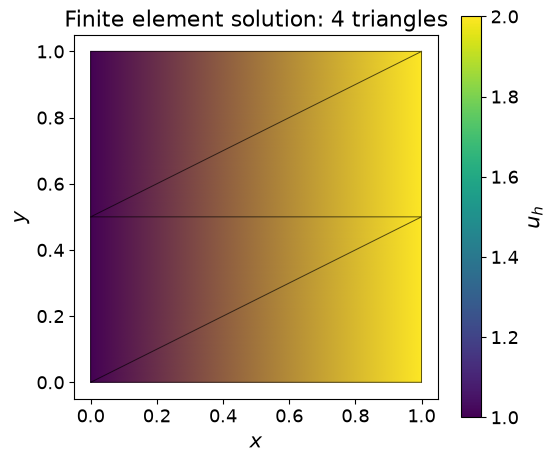

In [6]:
domain, V, u_h, h_mesh, error_L2 = solve_diffusion(1, 2)
print("Triangles:", domain.topology.index_map(2).size_global)
print("Degrees of freedom:", V.dofmap.index_map.size_global)
print(f"h = {h_mesh:.6f}, L2 error = {error_L2:.6e}")

fig, ax = plt.subplots(figsize=(5.8, 5.0))
image = draw_field(ax, V, u_h.x.array.real, "Finite element solution: 4 triangles")
fig.colorbar(image, ax=ax, label=r"$u_h$")
fig.tight_layout()
plt.show()

## 4. Uniform refinement and $L^2$ error

Starting from 4 triangles, double the number of subdivisions in each coordinate. The resulting mesh sizes are $h$, $h/2$, and $h/4$.

In [7]:
mesh_counts = [(1, 2), (2, 4), (4, 8)]
solutions = []
mesh_sizes = []
errors_L2 = []

for nx, ny in mesh_counts:
    domain, V, u_h, h_mesh, error_L2 = solve_diffusion(nx, ny)
    solutions.append((domain, V, u_h))
    mesh_sizes.append(h_mesh)
    errors_L2.append(error_L2)
    print(
        f"{domain.topology.index_map(2).size_global:2d} triangles: "
        f"h = {h_mesh:.6f}, L2 error = {error_L2:.6e}"
    )

 4 triangles: h = 1.118034, L2 error = 1.290994e-01
16 triangles: h = 0.559017, L2 error = 3.869513e-02
64 triangles: h = 0.279508, L2 error = 1.079126e-02


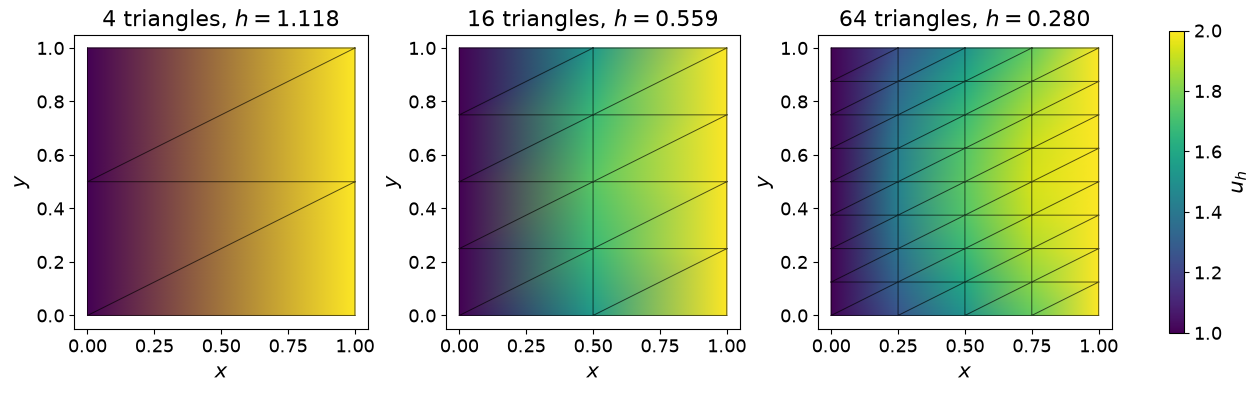

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0), constrained_layout=True)
for ax, (domain, V, u_h), h_mesh in zip(axes, solutions, mesh_sizes):
    n_triangles = domain.topology.index_map(2).size_global
    image = draw_field(
        ax, V, u_h.x.array.real,
        rf"{n_triangles} triangles, $h={h_mesh:.3f}$"
    )
fig.colorbar(image, ax=axes, shrink=0.82, label=r"$u_h$")
plt.show()

Observed L2 rates: [1.73825887 1.84228905]


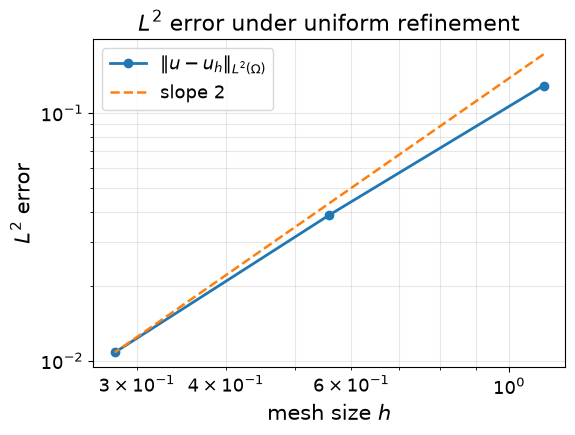

In [9]:
mesh_sizes = np.asarray(mesh_sizes)
errors_L2 = np.asarray(errors_L2)
observed_rates = np.log(errors_L2[:-1] / errors_L2[1:]) / np.log(2.0)
print("Observed L2 rates:", observed_rates)

fig, ax = plt.subplots(figsize=(6.0, 4.6))
ax.loglog(mesh_sizes, errors_L2, "o-", linewidth=2.0, label=r"$\|u-u_h\|_{L^2(\Omega)}$")
reference = errors_L2[-1] * (mesh_sizes / mesh_sizes[-1])**2
ax.loglog(mesh_sizes, reference, "--", linewidth=1.8, label=r"slope $2$")
ax.set(xlabel=r"mesh size $h$", ylabel=r"$L^2$ error", title=r"$L^2$ error under uniform refinement")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()